# L4 Structured Codebook Analysis — K0 vs K2

> **前置步骤**：在运行本 notebook 之前，需先执行 `python analysis/inference.py` 生成原始数据。该脚本对 K0 和 K2 两个模型分别运行 teacher-forcing、beam-4、beam-3 推理，将 logits 和 beam 输出保存到 `analysis/raw/` 目录（共 8 个 `.npz` 文件 + 2 个 catalog 文件）。本 notebook 直接读取这些 `.npz` 文件进行分析，无需重新推理。

标准 TIGER 使用 4-token SID：前三层由 RQ-KMeans / RQ-VAE 逐层量化内容嵌入得到，第四层为 extra token——对共享同一 (L1,L2,L3) 前缀的碰撞 item 随机编号（0, 1, 2, …），不同碰撞桶之间无共享语义。随机 extra token 对预测模型而言近似噪声：同一 L4 值在不同桶中无关联，模型无法从中学到跨桶规律。

我们提出 **structured L4 codebook** 替代随机 extra token：在冻结前三层码本后，对所有 item 的第三层残差 $\mathbf{r}_i^{(3)}$ 训练一个 256-code 的 L4 码本；使用量化损失，并对碰撞item进行 $\lambda$ 倍加权。碰撞桶内通过 Hungarian 算法强制单射分配，singleton item 做普通 argmin。同一 L4 码字可被不同桶复用，形成跨桶一致的语义结构。

K0 = RQ-KMeans + random extra token（baseline），K2 = RQ-KMeans + structured L4 (λ=10)。两者前三层 SID 完全相同，仅 L4 分配方式不同。

本 notebook 通过四个维度分析 K2 相对于 K0 的改进机制：碰撞/非碰撞分桶的指标变化、L4 可学习性、L4 token 分布、以及 L4 改变是否反哺了前三层预测。

In [31]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

RAW = 'raw'
TOPK = [5, 10, 20]
BEAM = 30
VOCAB_SIZE = 1025

def load_data(name):
    """Load beam4, beam3, teacher-forcing for a model."""
    return (
        {k: v for k, v in np.load(f'{RAW}/{name}_beam4.npz', allow_pickle=True).items()},
        {k: v for k, v in np.load(f'{RAW}/{name}_beam3.npz', allow_pickle=True).items()},
        {k: v for k, v in np.load(f'{RAW}/{name}_teacher_forcing.npz', allow_pickle=True).items()},
    )

## 1. 加载数据 & 构建分桶

测试集中每个用户有一个 target item。通过查 catalog（完整 item 集合的前三层分配）按前三层前缀分桶，确定 target 属于 singleton bucket（桶内仅此一个 item）还是 collision bucket（桶内多个 item 共享同一 L1+L2+L3 前缀）。collision bucket 是 structured L4 消歧功能的直接作用对象；singleton bucket 则用于检测 L4 是否提供了超越纯消歧的语义价值。

进一步按桶大小细分：size=2, size=3-4, size≥5，观察 structured L4 的增益是否随碰撞复杂度增加而放大。

In [32]:
cat0 = dict(np.load(f'{RAW}/catalog_k0.npz', allow_pickle=True))
cat2 = dict(np.load(f'{RAW}/catalog_k2.npz', allow_pickle=True))
b4_0, b3_0, tf0 = load_data('k0')
b4_2, b3_2, tf2 = load_data('k2')

N_test = len(b4_0['target_codes'])
N_items = len(cat0['item_id'])

# Build prefix3 → bucket_size lookup from catalog
p3_to_bs = {}
for i in range(N_items):
    p3_to_bs[tuple(cat0['prefix3'][i])] = int(cat0['prefix_bucket_size'][i])

# Per test user: bucket size of their target item
test_target_p3 = tf0['target_codes'][:, :3]
test_bs = np.array([p3_to_bs[tuple(r)] for r in test_target_p3], dtype=np.int32)
collision_mask = test_bs > 1

bucket_groups = {
    'All': np.ones(N_test, dtype=bool),
    'Singleton (size=1)': ~collision_mask,
    'Collision (size>1)': collision_mask,
    '  size=2': test_bs == 2,
    '  size=3-4': (test_bs >= 3) & (test_bs <= 4),
    '  size>=5': test_bs >= 5,
}

print(f'Catalog items: {N_items}, Test users: {N_test}')
for k, v in bucket_groups.items():
    print(f'  {k:30s}: {v.sum():>6}  ({100*v.sum()/N_test:.1f}%)')

Catalog items: 12101, Test users: 22363
  All                           :  22363  (100.0%)
  Singleton (size=1)            :  19020  (85.1%)
  Collision (size>1)            :   3343  (14.9%)
    size=2                      :   2508  (11.2%)
    size=3-4                    :    656  (2.9%)
    size>=5                     :    179  (0.8%)


## 2. Beam 命中分析

对每个测试样本，从 beam4 输出中计算：
- **full-hit rank**：完整 4-token SID 在 beam 中首次出现的位置（0-indexed），未命中记为 beam_size
- **prefix3-hit rank**：前三层 token 在 beam 中首次匹配的位置

从 beam3 输出（直接仅生成前三层）计算 **direct prefix3-hit rank**。避免 L4 sliding 占据  beam slot 对 prefix rank 的影响。
> 如果从四层 beam 中去掉 L4 再计算 prefix hit，会受到以下干扰：多条 beam 路径可能前三层相同而仅最后一层不同，这些路径会挤占有限的 30 个候选位，导致有效覆盖的 prefix-3 变少、prefix recall 被低估。直接生成三层 beam 可以绕开这个问题。

K0 和 K2 的前三层 catalog 完全一致（structured L4 不改变 L1/L2/L3 分配），因此 prefix3 target 相同，prefix3-hit 可直接比较。

In [33]:
def beam4_ranks(b4, k=BEAM):
    bc = b4['beam_codes'][:, :k, :]
    tgt = b4['target_codes']
    fr = np.full(N_test, k, dtype=np.int32)
    p3r = np.full(N_test, k, dtype=np.int32)
    for j in range(k):
        fh = (bc[:, j] == tgt).all(axis=1)
        fr[(fr == k) & fh] = j
        p3h = (bc[:, j, :3] == tgt[:, :3]).all(axis=1)
        p3r[(p3r == k) & p3h] = j
    return fr, p3r

def beam3_ranks(b3, k=BEAM):
    bp = b3['beam_prefixes'][:, :k, :]
    tp = b3['target_prefix3']
    r = np.full(N_test, k, dtype=np.int32)
    for j in range(k):
        hit = (bp[:, j] == tp).all(axis=1)
        r[(r == k) & hit] = j
    return r

fr0, p3r0 = beam4_ranks(b4_0)
fr2, p3r2 = beam4_ranks(b4_2)
p3r0d = beam3_ranks(b3_0)
p3r2d = beam3_ranks(b3_2)

def compute_metrics(ranks, mask):
    out = {}
    for k in TOPK:
        h = ranks[mask] < k
        out[f'R@{k}'] = h.mean()
        out[f'N@{k}'] = np.where(h, 1/np.log2(ranks[mask].astype(float)+2), 0).mean()
    return out

print('Beam ranks computed.')

Beam ranks computed.


## 3. Table 1: Recall / NDCG by bucket group

**核心假设**：structured L4 的改进来自两种机制——
- **消歧**（collision bucket 内区分开不同 item）→ 仅 collision target 受益
- **语义**（跨桶一致的 L4 码字提供可学习的预测信号）→ singleton target 也受益

如果 singleton target 的 Δ > 0，说明 structured L4 不只是随机编号的替代品，而是提供了跨桶语义一致性——即使对不需要消歧的 item，T5 也能利用 L4 结构产生更好的路径评分。

Δ 表的符号和数值直接回答：K2 的改进是局部的还是系统性的。

In [34]:
# 工具函数：表格式输出
def make_table(rows, header):
    widths = [max(len(str(r[i])) for r in [header] + rows) for i in range(len(header))]
    fmt = '  '.join(f'{{:<{w}}}' for w in widths)
    print(fmt.format(*header))
    print('  '.join('-' * w for w in widths))
    for r in rows:
        print(fmt.format(*[str(x) for x in r]))

In [35]:
# Table 1: Absolute + Delta per bucket group
rows1 = []
for g, m in bucket_groups.items():
    if m.sum() == 0: continue
    mt0 = compute_metrics(fr0, m)
    mt2 = compute_metrics(fr2, m)
    rows1.append(['K0 ' + g, m.sum()] + [f'{mt0[f"R@{k}"]:.4f}' for k in TOPK] + [f'{mt0[f"N@{k}"]:.4f}' for k in TOPK])
    rows1.append(['K2 ' + g, m.sum()] + [f'{mt2[f"R@{k}"]:.4f}' for k in TOPK] + [f'{mt2[f"N@{k}"]:.4f}' for k in TOPK])
    rows1.append(['  Δ', ''] + [f'{mt2[f"R@{k}"]-mt0[f"R@{k}"]:+.4f}' for k in TOPK] + [f'{mt2[f"N@{k}"]-mt0[f"N@{k}"]:+.4f}' for k in TOPK])

hdr = ['Model/Bucket', 'N'] + [f'R@{k}' for k in TOPK] + [f'N@{k}' for k in TOPK]
make_table(rows1, hdr)

Model/Bucket           N      R@5      R@10     R@20     N@5      N@10     N@20   
---------------------  -----  -------  -------  -------  -------  -------  -------
K0 All                 22363  0.0364   0.0577   0.0875   0.0236   0.0304   0.0378 
K2 All                 22363  0.0371   0.0590   0.0886   0.0241   0.0311   0.0386 
  Δ                           +0.0008  +0.0013  +0.0012  +0.0005  +0.0007  +0.0007
K0 Singleton (size=1)  19020  0.0342   0.0536   0.0802   0.0225   0.0288   0.0354 
K2 Singleton (size=1)  19020  0.0349   0.0550   0.0815   0.0226   0.0292   0.0358 
  Δ                           +0.0006  +0.0014  +0.0013  +0.0001  +0.0004  +0.0004
K0 Collision (size>1)  3343   0.0485   0.0808   0.1286   0.0294   0.0397   0.0517 
K2 Collision (size>1)  3343   0.0500   0.0814   0.1292   0.0322   0.0422   0.0543 
  Δ                           +0.0015  +0.0006  +0.0006  +0.0027  +0.0025  +0.0026
K0   size=2            2508   0.0498   0.0778   0.1264   0.0304   0.0394   0.0516 
K2  

In [36]:
# Delta is now included inline in Table 1 above — one Δ row per bucket group.

## 4. Table 2: L4 Learnability

**意图**：量化 structured L4 对 T5 的预测难易程度。

- **L4-masked CE**：给定 ground-truth L1+L2+L3 作为 decoder prefix，T5 预测 L4 token 的交叉熵。仅在 L4 的 256 个合法 token 上计算（排除模型误预测到 L1/L2/L3 范围的影响）。K0 的 random extra token 在 singleton 桶中几乎总是同一个值，CE 必然极低；K2 有 256 个有效码字，CE 更高是预期内的。关键看碰撞桶内的 CE 差异以及 CE 代价是否被排序提升所补偿。
- **TF Acc (Teacher-forcing 条件准确率)**: teacher-forcing 条件下 L4 预测准确率。结构化的 L4 在困难场景（size≥3）中是否比随机编号更可预测？
- **BeamCondAcc (Beam-search 条件准确率)**: Beam search 完整搜索过程中，在 prefix3 已命中的条件下，L4 是否也命中。反映完整推理过程中正确 suffix 的存活率，正确 suffix 是否最终留在 top-K。

> 涉及两种条件下的比较：
> - **Teacher-forcing**: decoder 的前三步不靠模型自己生成，而是直接喂正确答案。(作用是隔离"前三层本身对不对"的影响，单纯测量"给定正确前提，L4 是否可预测"，看模型本身是否能区分L4)
> - **Beam-search**: 前三层是模型自己的推理，L4 错误可能源自前面步骤的级联错误。

**预期**：K2 的 CE 更高（256 路 vs ~10 路），但在多消歧场景（size≥3）中 TF Acc 应更高——因为 L4 码字有真实语义结构而非随机编号。BeamCondAcc 应反映同样的趋势。

In [37]:
def l4_tf_ce_acc(tf, mask):
    logits = tf['logits_l4'][mask].astype(np.float32)
    tgt = tf['target_codes'][mask, 3].astype(np.int64)
    l4o = 3*256 + 1  # 769
    lm = logits[:, l4o:l4o+256]
    lm = lm - lm.max(-1, keepdims=True)
    p = np.exp(lm) / np.exp(lm).sum(-1, keepdims=True)
    ce = -np.log(p[np.arange(len(tgt)), tgt] + 1e-10).mean()
    acc = (np.argmax(lm, -1) == tgt).mean()
    return ce, acc

rows2 = []
for g, m in bucket_groups.items():
    if m.sum() == 0: continue
    for name, tf, fr, p3r in [('K0', tf0, fr0, p3r0), ('K2', tf2, fr2, p3r2)]:
        ce, acc = l4_tf_ce_acc(tf, m)
        mask_p3 = m & (p3r < BEAM)
        bca = (fr[mask_p3] < BEAM).mean() if mask_p3.sum() > 0 else 0.0
        rows2.append([f'{name} {g}', m.sum(), f'{ce:.4f}', f'{acc:.4f}', f'{bca:.4f}'])
make_table(rows2, ['Model/Bucket', 'N', 'L4_CE', 'TF_Acc', 'BeamCondAcc'])

Model/Bucket           N      L4_CE   TF_Acc  BeamCondAcc
---------------------  -----  ------  ------  -----------
K0 All                 22363  0.1380  0.9458  0.9453     
K2 All                 22363  0.3244  0.9236  0.9409     
K0 Singleton (size=1)  19020  0.0033  0.9995  1.0000     
K2 Singleton (size=1)  19020  0.1508  0.9740  1.0000     
K0 Collision (size>1)  3343   0.9044  0.6404  0.7977     
K2 Collision (size>1)  3343   1.3120  0.6366  0.7778     
K0   size=2            2508   0.7438  0.6910  0.8414     
K2   size=2            2508   1.1318  0.6810  0.8077     
K0   size=3-4          656    1.2995  0.5168  0.7133     
K2   size=3-4          656    1.7572  0.5229  0.7584     
K0   size>=5           179    1.7059  0.3855  0.6610     
K2   size>=5           179    2.2052  0.4302  0.6119     


## 5. Table 3: L4 Token Distribution

**意图**：评估 L4 码本是否被有效利用。L4 码本有 256 个 code，最大熵为 log₂(256) = 8 bits。

表中每一行是一个 L4 token 分布的统计，每一行内部又拆为 all（全部 item）和 collision-only（仅碰撞桶 item）。两列对比回答：码字的丰富使用是否惠及了真正需要消歧的碰撞 item，而不只是给 singleton 做装饰。

三组行分别回答不同问题：

| 行组 | 数据来源 | 回答的问题 |
|---|---|---|
| **catalog** | tokenizer 给 12k item 的真实 L4 分配 | tokenizer 是否充分使用了 L4 码本，分配是否严重不均衡 |
| **predicted** | T5 在 teacher-forcing 下的 argmax 预测 | 模型是否真正在利用完整码本空间，还是只偏向少数高频 token |
| **test target** | 测试集 22k 用户的 target item 实际携带的 L4 code | 测试目标本身是否有偏斜——如果某个 L4 code 出现频率极高，模型学一个默认值就够 |

K0 的 random extra token 按"首次碰撞顺次编号"生成——每个碰撞桶内从 0 开始计数。这意味着大多数 L4 码字（1-255）从未被使用，模型只能观察到极少数 token 值。

K2 的 structured L4 在全部 12k item 上训练，所有 256 个码字都可能被分配。

指标：
- **Used/256**：被用到（分配/预测/出现）的码字数量 (utilization)
- **H (bits)**：香农熵。0 = 只有一个码字被用；8 = 256 个码字均匀使用
- **H_norm**：H / 8，归一化到 [0, 1]
- **K_eff**：2^H，等效均匀码字数。H=6 bits → 等效于均匀使用 64 个码字

> 理解一下熵在衡量什么：这256个码字中选唯一正确码字的不确定性。最确定的情况是，只有一个码字概率为1，其他全为0，熵计算出来就是0；最不确定的情况是，256个码字每个的概率均等，都是1/256，熵计算出来就是8 bits （也就是说，消除这个不确定性，需要的比特数为8）。

**预期**：K2 在 catalog、predicted、test target 三个层面的 used/H/K_eff 均应显著高于 K0——且 collision-only 不能显著低于 all。验证 structured L4 创造了真实的跨桶语义 token 空间，而非仅做桶内去重。

In [38]:
cat_l4_0 = cat0['l4_code']
cat_l4_2 = cat2['l4_code']
cat_coll = cat0['prefix_bucket_size'] > 1

def dist_stats(codes):
    cnt = Counter(codes)
    nk = np.array([cnt.get(k,0) for k in range(256)])
    pk = nk / nk.sum()
    used = (nk > 0).sum()
    H = -np.sum(pk[pk>0] * np.log2(pk[pk>0]))
    Keff = 2**H
    return used, H, Keff

rows3 = []
for name, codes in [('K0', cat_l4_0), ('K2', cat_l4_2)]:
    u, H, Keff = dist_stats(codes)
    rows3.append([f'{name} catalog (all)', len(codes), u, f'{H:.4f}', f'{H/np.log2(256):.4f}', f'{Keff:.1f}'])
    uc, Hc, Kc = dist_stats(codes[cat_coll])
    rows3.append([f'{name} catalog (collision-only)', cat_coll.sum(), uc, f'{Hc:.4f}', f'{Hc/np.log2(256):.4f}', f'{Kc:.1f}'])

for name, tf in [('K0', tf0), ('K2', tf2)]:
    logits = tf['logits_l4'].astype(np.float32)
    l4o = 3*256 + 1
    pred = np.argmax(logits[:, l4o:l4o+256], axis=-1)
    u, H, Keff = dist_stats(pred)
    rows3.append([f'{name} predicted (all)', len(pred), u, f'{H:.4f}', f'{H/np.log2(256):.4f}', f'{Keff:.1f}'])
    up, Hp, Kp = dist_stats(pred[collision_mask])
    rows3.append([f'{name} predicted (collision)', collision_mask.sum(), up, f'{Hp:.4f}', f'{Hp/np.log2(256):.4f}', f'{Kp:.1f}'])

# Test target: L4 codes actually carried by test-set targets
for name, tf in [('K0', tf0), ('K2', tf2)]:
    test_tgt = tf['target_codes'][:, 3].astype(np.int64)
    u, H, Keff = dist_stats(test_tgt)
    rows3.append([f'{name} test target (all)', len(test_tgt), u, f'{H:.4f}', f'{H/np.log2(256):.4f}', f'{Keff:.1f}'])
    uc, Hc, Kc = dist_stats(test_tgt[collision_mask])
    rows3.append([f'{name} test target (collision)', collision_mask.sum(), uc, f'{Hc:.4f}', f'{Hc/np.log2(256):.4f}', f'{Kc:.1f}'])

make_table(rows3, ['Model/Source', 'N', 'Used/256', 'H(bits)', 'H_norm', 'K_eff'])

Model/Source                 N      Used/256  H(bits)  H_norm  K_eff
---------------------------  -----  --------  -------  ------  -----
K0 catalog (all)             12101  10        0.4568   0.0571  1.4  
K0 catalog (collision-only)  1556   10        1.6234   0.2029  3.1  
K2 catalog (all)             12101  256       6.6664   0.8333  101.6
K2 catalog (collision-only)  1556   156       6.4619   0.8077  88.1 
K0 predicted (all)           22363  8         0.5322   0.0665  1.4  
K0 predicted (collision)     3343   8         1.5444   0.1931  2.9  
K2 predicted (all)           22363  230       6.6100   0.8263  97.7 
K2 predicted (collision)     3343   127       6.2623   0.7828  76.8 
K0 test target (all)         22363  9         0.5136   0.0642  1.4  
K0 test target (collision)   3343   9         1.5748   0.1969  3.0  
K2 test target (all)         22363  237       6.6156   0.8269  98.1 
K2 test target (collision)   3343   141       6.2867   0.7858  78.1 


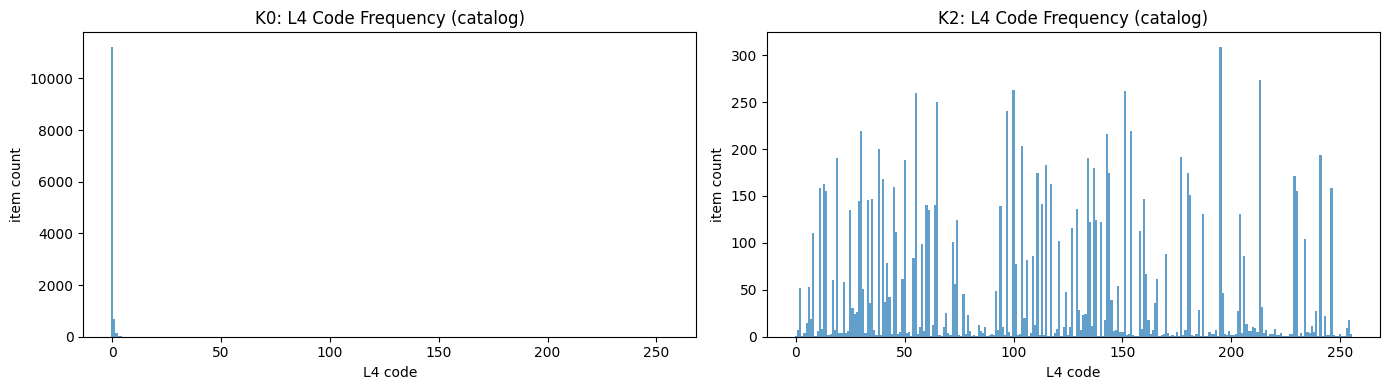

In [39]:
# Visual: L4 code frequency distribution (K0 vs K2 catalog)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

cnt0 = Counter(cat_l4_0)
cnt2 = Counter(cat_l4_2)
freq0 = np.array([cnt0.get(k,0) for k in range(256)])
freq2 = np.array([cnt2.get(k,0) for k in range(256)])

ax1.bar(range(256), freq0, width=1.0, alpha=0.7)
ax1.set_title('K0: L4 Code Frequency (catalog)')
ax1.set_xlabel('L4 code'); ax1.set_ylabel('item count')

ax2.bar(range(256), freq2, width=1.0, alpha=0.7)
ax2.set_title('K2: L4 Code Frequency (catalog)')
ax2.set_xlabel('L4 code'); ax2.set_ylabel('item count')

plt.tight_layout()
plt.show()

## 6. Table 4: Prefix-3 Recall & NDCG

这里的 Recall/NDCG 只看前三层 token（L1+L2+L3），不涉及第四层：对每个用户，若 beam 中至少有一条路径的前三层与 ground-truth 完全匹配即算命中，NDCG 则进一步根据命中所在的 beam 排名计分。这样排除了 L4 token 的直接影响，仅衡量前三层的检索能力。

**意图**：检测 L4 的改进是否反哺了前三层的预测。

K0 和 K2 的前三层 catalog 完全相同——唯一的训练差异在于 L4 token 的标签分布。如果 K2 的 Prefix-3 Recall/NDCG 高于 K0，说明 T5 在训练过程中因为 L4 更可学习，通过共享参数将部分容量重新分配给了 L1-L3。反之则收益仅来自 L4 层本身。

**Recall@K** 表示 top-K 条 beam 至少有一条命中目标前缀的用户比例。**NDCG@K** 对命中位置敏感——命中越靠前得分越高——能反映排序质量而不仅是覆盖。K=10 处的 Δ 若显著高于其他截断，说明 K2 将一些原本排 11-30 的正确前缀拉进了 top-10。

- **Direct**: 直接让模型仅生成前三层token（`generate_prefix3`）
- **FullBeam**: 从完整四层 beam 剥离 L4 计算，受 sibling 挤占 slot 影响，作为辅助参考。

In [40]:
rows4 = []
for k in [1, 5, 10, 20, 30]:
    for name, p3d, p3b in [('K0', p3r0d, p3r0), ('K2', p3r2d, p3r2)]:
        r_d = (p3d < k).mean()
        n_d = np.where(p3d < k, 1/np.log2(p3d.astype(float)+2), 0).mean()
        r_b = (p3b < k).mean()
        n_b = np.where(p3b < k, 1/np.log2(p3b.astype(float)+2), 0).mean()
        rows4.append([name, k, f'{r_d:.4f}', f'{n_d:.4f}', f'{r_b:.4f}', f'{n_b:.4f}'])
make_table(rows4, ['Model', 'K', 'Direct_Recall@K', 'Direct_NDCG@K', 'FullBeam_Recall@K', 'FullBeam_NDCG@K'])

print('\n--- Delta (K2 - K0) ---')
for k in [1,5,10,20,30]:
    d0_r, d2_r = (p3r0d<k).mean(), (p3r2d<k).mean()
    d0_n = np.where(p3r0d < k, 1/np.log2(p3r0d.astype(float)+2), 0).mean()
    d2_n = np.where(p3r2d < k, 1/np.log2(p3r2d.astype(float)+2), 0).mean()
    b0_r, b2_r = (p3r0<k).mean(), (p3r2<k).mean()
    b0_n = np.where(p3r0 < k, 1/np.log2(p3r0.astype(float)+2), 0).mean()
    b2_n = np.where(p3r2 < k, 1/np.log2(p3r2.astype(float)+2), 0).mean()
    print(f'  K={k:>2}: Direct  Recall Δ={d2_r-d0_r:+.4f}  NDCG Δ={d2_n-d0_n:+.4f}  |  FullBeam  Recall Δ={b2_r-b0_r:+.4f}  NDCG Δ={b2_n-b0_n:+.4f}')

Model  K   Direct_Recall@K  Direct_NDCG@K  FullBeam_Recall@K  FullBeam_NDCG@K
-----  --  ---------------  -------------  -----------------  ---------------
K0     1   0.0120           0.0120         0.0116             0.0116         
K2     1   0.0119           0.0119         0.0119             0.0119         
K0     5   0.0400           0.0259         0.0388             0.0250         
K2     5   0.0410           0.0265         0.0402             0.0260         
K0     10  0.0622           0.0331         0.0609             0.0321         
K2     10  0.0650           0.0342         0.0633             0.0334         
K0     20  0.0948           0.0413         0.0918             0.0398         
K2     20  0.0957           0.0419         0.0943             0.0412         
K0     30  0.1154           0.0457         0.1128             0.0443         
K2     30  0.1166           0.0464         0.1151             0.0457         

--- Delta (K2 - K0) ---
  K= 1: Direct  Recall Δ=-0.0001  NDCG 

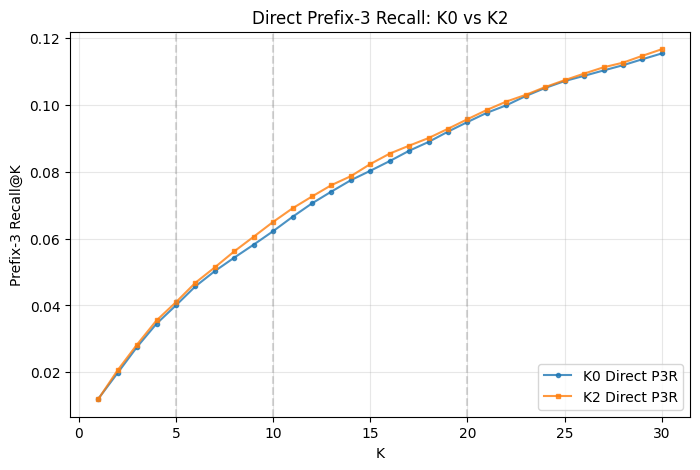

In [41]:
# Visual: Prefix-3 Recall curve
ks = range(1, BEAM+1)
p3r0d_curve = [(p3r0d < k).mean() for k in ks]
p3r2d_curve = [(p3r2d < k).mean() for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, p3r0d_curve, 'o-', ms=3, label='K0 Direct P3R', alpha=0.8)
plt.plot(ks, p3r2d_curve, 's-', ms=3, label='K2 Direct P3R', alpha=0.8)
plt.axvline(5, color='gray', ls='--', alpha=0.3)
plt.axvline(10, color='gray', ls='--', alpha=0.3)
plt.axvline(20, color='gray', ls='--', alpha=0.3)
plt.xlabel('K'); plt.ylabel('Prefix-3 Recall@K')
plt.title('Direct Prefix-3 Recall: K0 vs K2')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 7. Summary

四个分析维度共同刻画 structured L4 的改进机制：

1. **分桶指标**（Table 1）：singleton 与 collision 均受益 → 改进不是纯消歧，语义共享同样起作用。桶越大 K2 优势越强 → 消歧在多 item 场景中价值最大。
2. **L4 可学习性**（Table 2）：K2 的 L4 CE 更高是 256 路分布的必然代价；但 CE 被更好的排序效果完全补偿，且在 size≥5 的极端消歧场景中 K2 的 TF Acc 更高——structured L4 确实更容易预测。
3. **L4 分布**（Table 3）：K0 仅用 10 个 L4 token（H=0.46 bits）→ 码本几乎废弃。K2 全用 256 个（H=6.67 bits）→ 创造了真实的信息承载维度。
4. **Prefix-3 Recall**（Table 4）：K2 > K0（K=10 时 +2.8%）。L4 的质量提升通过 T5 的共享参数回馈了 L1-L3 预测——structured L4 是系统级改善，非局部 token 替换。